In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import numpy as np
import scipy
import copy

from scipy.sparse import coo_matrix, block_diag, identity, hstack, csr_matrix, csc_matrix, vstack
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import time 

from pyiga import assemble, bspline, vform, geometry, vis, solvers, utils, topology, ieti, algebra, operators, adaptive
from pyiga import algebra_cy, ieti_cy, bspline_cy

from scipy.sparse.linalg import aslinearoperator as LinOp

np.set_printoptions(linewidth=100000)
np.set_printoptions(precision=5)

In [2]:
def Lshape(deg, N, k=1):
    kvs = [2 * (bspline.make_knots(deg, 0.0, 1.0, N, mult=k),),2 * (bspline.make_knots(deg, 0.0, 1.0, N, mult=k),)]

    # define geometry
    geos = [
        geometry.Quad(np.array([[-1,-1],[0,-1],[-1,1],[0,0]]).T),
        geometry.Quad(np.array([[-1,1],[0,0],[1,1],[1,0]]).T)
    ]

    patches = [(k, g) for k, g in zip(kvs,geos)]
    M = topology.MultiPatch(patches)
    return M

In [3]:
def LshapeAnullus(deg, N, k=1):
    kvs = 3*[2 * (bspline.make_knots(deg, 0.0, 1.0, N, mult=k),)]

    # define geometry
    geos = [
        geometry.annulus(r1=1.5, r2=2, phi = np.pi/4),
        geometry.annulus(r1=1.5, r2=2, phi = np.pi/4).rotate_2d(angle=np.pi/4),
        geometry.annulus(r1=1.0, r2=1.5, phi = np.pi/4).rotate_2d(angle=np.pi/4)
    ]

    patches = [(k, g) for k, g in zip(kvs,geos)]
    M = topology.MultiPatch(patches)
    M.outer_boundaries[0].add((1,(0,0)))
    return M

In [4]:
def cart2pol(x, y):
    r = np.sqrt(x**2 + y**2)
    phi = np.arctan2(y, x)
    return(r, phi%(2*np.pi))
def u(x,y):
    r, phi = cart2pol(x,y)
    return r**(2/3)*np.sin(2*phi/3)
def ux(x,y):
    r, phi = cart2pol(x,y)
    return -2./3*r**(-1./3)*np.sin(phi/3)
def uy(x,y):
    r, phi = cart2pol(x,y)
    return 2./3*r**(-1./3)*np.cos(phi/3)

In [205]:
degs = (2,3,5,8)
maxpatches =(1500,1500,1500,1200)
level = (3,3,3,3,3,3)
maxiter=30
maxN=0

direct=False

prim = {'v':1, 'e':0}
R = np.zeros((1000,5*len(degs)))

example=1

f=1
g=0

plot=0
dir_data={0:g}
U=[]
eta=[]

for i,deg in enumerate(degs):
    N = deg+1
    M = LshapeAnullus(deg,N,1)

    IMap = ieti.IetiMapper(M, dir_data=dir_data, subspace='C0', elim=0)
    
    k=0
    while k < maxiter:
        if plot:
            M.plotmesh(figsize=(10,10), knots=1, nodes=50, bwidth=0.01, patch_idx=0)
            plt.axis('off');
            plt.axis('scaled');
            plt.savefig('/home/wolfman/Pictures/p'+str(deg)+'i'+str(k)+'.png',dpi=100,bbox_inches='tight');
            plt.show();
            plt.close();

        ### SOLVE
        A, RHS = IMap.assemble(a=1,f=f, M=None)
        N = [A.shape[0] for A in A]
            
        Prim = csc_matrix((IMap.N_ofs_elim[-1],0))

        if bool(prim['v']):
            PrimV, to_be_eliminated = IMap.nodes_as_primals(dir_boundary=False)
            Prim = scipy.sparse.hstack([Prim, PrimV])
        if bool(prim['e']):
            Prim = scipy.sparse.hstack([Prim, IMap.interface_averages_as_primals(1)])

        B, eliminated_constraints = IMap.ConstraintMatrices(eliminate=to_be_eliminated)
        SD = ieti.ScaledDirichletPreconditioner(A, B, IMap)

        nPrim=Prim.shape[1]

        R[k,i*5+3]=nPrim
        R[k,i*5+4]=IMap.nPatches

        if nPrim==0:
            I = ieti.IetiSystem(A, B, RHS, N)
            F, b = I.SchurComplement(), I.RHSforSchurComplement()
            C = [scipy.sparse.csr_matrix((0,A[p].shape[1])) for p in range(len(B))]
        else:
            primal = ieti.PrimalSystem(Prim)
            modA, modB, modRHS, C = primal.incorporate_PrimalConstraints(A, B, RHS, IMap)
    
            loc_solver = primal.compute_PrimalBasis(modA, modB, modRHS, C)
            
            modA.append(primal.A_prim), modB.append(primal.B_prim), modRHS.append(primal.RHS_prim)
            loc_solver.append(solvers.make_solver(primal.A_prim, spd=True, symm=True)), N.append(primal.A_prim.shape[0])
            
            I = ieti.IetiSystem(modA, modB, modRHS, N, loc_solver)
            F, b = I.SchurComplement(), I.RHSforSchurComplement()

        SD.setupSelectionScaling()
        #SD.setupConstraintScaling()
        
        Prec1 = SD.AsOperator()
        lam, it, min_eig, max_eig, r = solvers.pcg(F, b, x0=None, maxiter=2000, P=Prec1, output=1, rtol=1e-6, atol=1e-12)
        R[k,i*5+1] = it
        R[k,i*5+2] = max_eig/min_eig

        uh = I.constructSolutionFromLagrangeMultipliers(lam)
        if nPrim>0:
            uh = primal.distributePrimalSolution(uh)
        uh = np.concatenate(IMap.completeDirichlet(uh))
        if IMap.elim:
            uh = IMap.Basis_loc_global@uh

        # U.append(u)

        # dir_bcs = IMap.set_fixed_boundary(dir_data, local=False)
        # Mh = IMap.assemble_volume("u * v * dx", arity=2, domain_id=0)
        # Kh = IMap.assemble_volume("inner(grad(u),grad(v)) * dx", arity=2, domain_id=0)
        # Fh = IMap.assemble_volume("(f * v) * dx", arity=1, domain_id=0, f=f)
        # LS = assemble.RestrictedLinearSystem(Kh, Fh, dir_bcs)
        # uh = LS.complete(solvers.make_solver(LS.A, spd=True)@LS.b)

        # u_load = IMap.assemble_volume("(f * v) * dx", arity=1, domain_id=0, f=u)
        # u_exact = operators.make_solver(Mh,spd=True)@u_load
        # eh = u_exact-uh
        # U.append(uh)

        # L2err = np.sqrt(eh.T@Mh@eh)
        # Eerr = np.sqrt(eh.T@Kh@eh)

        # if plot:
        #     IMap.plot(uh,mesh=True)
        #     plt.show()

        err_ind=adaptive.mp_resPois(IMap, uh, nu=1, f=f)
        eta.append(np.linalg.norm(err_ind))
        R[k,i*5] = eta[-1]
        #print(eta[-1]/Eerr)

        print("Error Estimator: {:.3}".format(eta[-1]))
        marked_patches = adaptive.doerfler_mark(err_ind, theta=0.8, TOL=0.01)
        marked_patches = {p:None for p in marked_patches}

        if IMap.nPatches + 3*len(marked_patches) >= maxpatches[i]:
            break;

        P = IMap.h_refine(h_ref=marked_patches,ref="rs", return_P = True, in_subspace=True)
        # for m in range(len(U)):
        #     U[m] = P@U[m]

        k+=1
        print("#####################################################")

    maxN = max(maxN,k)
R=R[:maxN,:]
np.save("LshapeS_A",R)
    # P = IMap.h_refine(h_ref=-1,ref="rs", return_P = True, in_subspace=True)
    # P = IMap.p_refine(return_P = True, in_subspace=True)@P

    # L2err = np.zeros(len(U))
    # Eerr = np.zeros(len(U))
    
    # Mh = IMap.assemble_volume("u * v * dx", arity=2, domain_id=0)
    # Kh = IMap.assemble_volume("inner(grad(u),grad(v)) * dx", arity=2, domain_id=0)

    # u_load = IMap.assemble_volume("(f * v) * dx", arity=1, domain_id=0, f=u)
    # u_exact = operators.make_solver(Mh,spd=True)@u_load

    # for m in range(len(U)):
    #     eh = u_exact - P@U[m] 

    #     L2err[m]= np.sqrt(eh.T@Mh@eh)
    #     Eerr[m] = np.sqrt(eh.T@Kh@eh)

setting up constraints took 0.0024824142456054688 seconds.
Basis setup took 0.001537322998046875 seconds
pcg with preconditioned condition number κ ~ 1.536 stopped after 5 iterations with relres 4.201e-10 after 0.0187 seconds.
Error Estimator: 0.0382
setting up constraints took 0.020730257034301758 seconds.
Basis setup took 0.002793550491333008 seconds
#####################################################
pcg with preconditioned condition number κ ~ 3.807 stopped after 11 iterations with relres 1.622e-07 after 0.0489 seconds.
Error Estimator: 0.0348
setting up constraints took 0.026242971420288086 seconds.
Basis setup took 0.001825571060180664 seconds
#####################################################
pcg with preconditioned condition number κ ~ 6.441 stopped after 13 iterations with relres 9.117e-07 after 0.0837 seconds.
Error Estimator: 0.0239
setting up constraints took 0.05141925811767578 seconds.
Basis setup took 0.002094745635986328 seconds
####################################

setting up constraints took 0.0024518966674804688 seconds.
Basis setup took 0.0015532970428466797 seconds
pcg with preconditioned condition number κ ~ 13.38 stopped after 21 iterations with relres 8.626e-07 after 0.00453 seconds.


<Axes: >

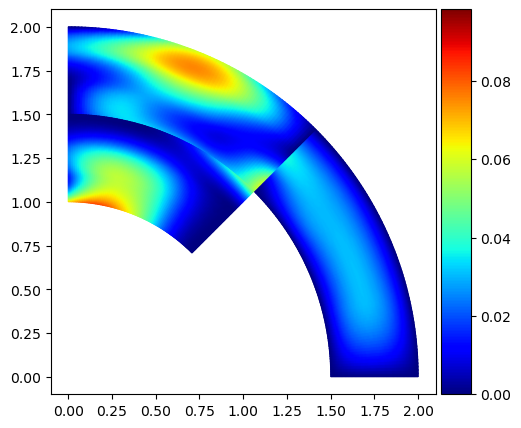

In [215]:
M = LshapeAnullus(2,3,1)
#M.outer_boundaries[0].remove((1,(0,0)))
IMap = ieti.IetiMapper(M, dir_data=dir_data, subspace='C0', elim=1)

A, RHS = IMap.assemble(a=1,f=f, M=None)
N = [A.shape[0] for A in A]

B, eliminated_constraints = IMap.ConstraintMatrices()
#SD = ieti.ScaledDirichletPreconditioner(A, B, IMap)

I = ieti.IetiSystem(A, B, RHS, N)
F, b = I.SchurComplement(), I.RHSforSchurComplement()

lam, it, min_eig, max_eig, r = solvers.pcg(F, b, x0=None, maxiter=2000, P=1, output=1, rtol=1e-6, atol=1e-12)

uh = I.constructSolutionFromLagrangeMultipliers(lam)
uh = np.concatenate(IMap.completeDirichlet(uh))
if IMap.elim:
    uh = IMap.Basis_loc_global@uh

IMap.plot(uh)

(<matplotlib.collections.QuadMesh at 0x7f23d83ae600>, <Axes: >)

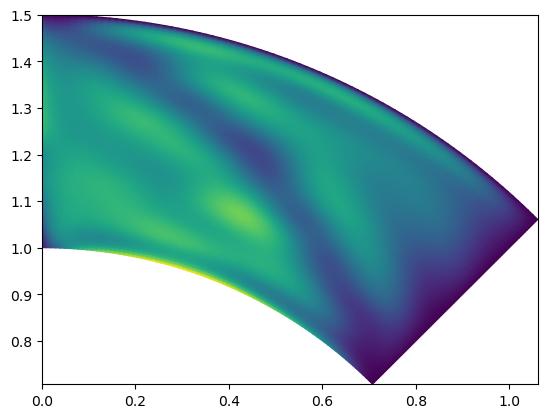

In [177]:
p=2
u_p = IMap.BCRestr[p].complete(np.linalg.inv(A[p].toarray())@RHS[p])
vis.plot_field(bspline.BSplineFunc(IMap.mesh.kvs[p],u_p), geo=IMap.mesh.geos[p])

In [163]:

bspline.BSplineFunc(IMap.mesh.kvs[p],u_p)

In [135]:
IMap.fixed_idx

{2: array([0, 1, 2, 4, 5, 6, 8], dtype=int32),
 0: array([0, 1, 2, 3, 5, 6, 8], dtype=int32),
 1: array([1, 2, 3, 4, 6, 8], dtype=int32)}

In [138]:
IMap.fixed_idx

{2: array([0, 1, 2, 3, 6, 7, 8]),
 0: array([0, 1, 2, 3, 5, 6, 8]),
 1: array([0, 2, 5, 6, 7, 8])}

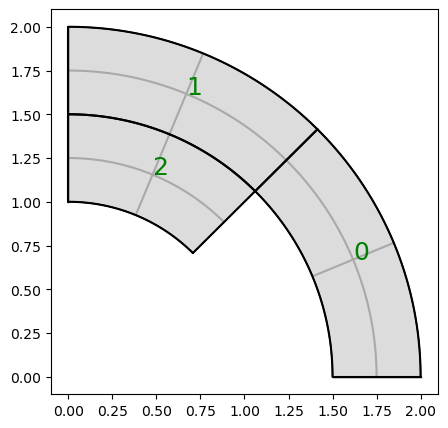

In [120]:
IMap.mesh.plotmesh(patch_idx=1, knots=1)

In [123]:
p=2
e=np.zeros(IMap.Xk[p].shape[1])
e[IMap.fixed_idx[p]]=1
np.where(IMap.Xk[p]@e)

(array([0, 1, 2, 3, 6, 7, 8]),)

In [112]:
dir_dof

array([ 0,  3,  7, 11, 12, 13, 14, 15])

In [27]:
M = Lshape(2,3,1)
M.h_refine({0:None})
# M.h_refine({1:-1,2:-1,3:-1,7:-1})

#M.h_refine({1:-1,2:-1,3:-1,7:-1})
dir_data={0:0}
f=1

In [28]:
IMap = ieti.IetiMapper(M, dir_data=dir_data, subspace='C0', elim=1)

setting up constraints took 0.015604496002197266 seconds.
Basis setup took 0.003610849380493164 seconds


In [29]:
IMap.B

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 60 stored elements and shape (30, 123)>

In [30]:
IMap.N_ofs_elim

array([  0,  25,  50,  75,  99, 123], dtype=int32)

In [31]:
A, RHS = IMap.assemble(a=1,f=f, M=None)
N = [A.shape[0] for A in A]

In [32]:
Prim, to_be_eliminated = IMap.nodes_as_primals(dir_boundary=False)

In [33]:
B, eliminated_constraints = IMap.ConstraintMatrices(eliminate=to_be_eliminated)
SD = ieti.ScaledDirichletPreconditioner(A, B, IMap)

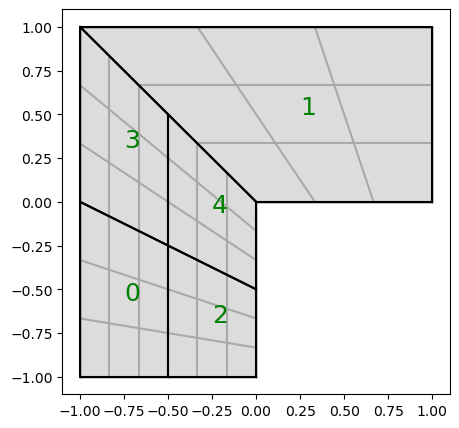

In [34]:
M.plotmesh(knots=1,patch_idx=1)

In [290]:
primal = ieti.PrimalSystem(Prim)
modA, modB, modRHS, C = primal.incorporate_PrimalConstraints(A, B, RHS, IMap)
    
loc_solver = primal.compute_PrimalBasis(modA, modB, modRHS, C)
            
modA.append(primal.A_prim), modB.append(primal.B_prim), modRHS.append(primal.RHS_prim)
loc_solver.append(solvers.make_solver(primal.A_prim, spd=True, symm=True)), N.append(primal.A_prim.shape[0])
            
I = ieti.IetiSystem(modA, modB, modRHS, N, loc_solver)
F, b = I.SchurComplement(), I.RHSforSchurComplement()

SD.setupSelectionScaling()
Prec = SD.AsOperator()

lam, it, min_eig, max_eig, r = solvers.pcg(F, b, x0=None, maxiter=2000, P=Prec, output=1, rtol=1e-6, atol=1e-12)

pcg with preconditioned condition number κ ~ 9.856 stopped after 13 iterations with relres 5.597e-07 after 3.08 seconds.


In [291]:
uh = I.constructSolutionFromLagrangeMultipliers(lam)
uh = primal.distributePrimalSolution(uh)
#uh = [IMap.Basis_loc[p][:,IMap.free[p]]@uh[p] for p in range(len(uh))]
uh = IMap.Basis_loc_global@np.concatenate(IMap.completeDirichlet(uh))

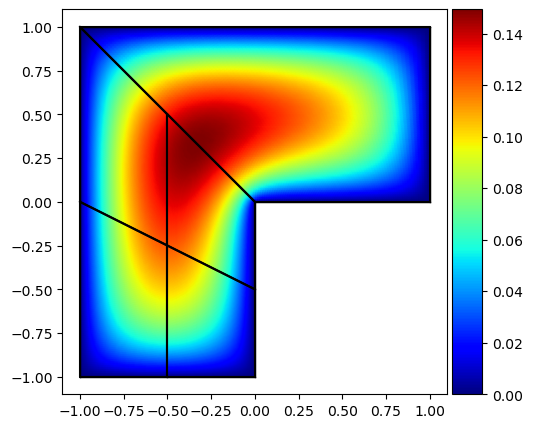

In [292]:
IMap.plot(uh,mesh=True);

In [226]:
Prim[:,2]

<Compressed Sparse Column sparse matrix of dtype 'float64'
	with 4 stored elements and shape (78, 1)>

In [17]:
X = (IMap.Basis_loc[2] == 1).astype(IMap.Basis_loc[2].dtype)

In [22]:
X[dofs,:]

<Compressed Sparse Column sparse matrix of dtype 'float64'
	with 4 stored elements and shape (4, 21)>

In [13]:
X[dofs,:].indices

array([1, 0, 2, 3], dtype=int32)

In [42]:
np.unique(IMap.Basis_loc[2][dofs,:].indices)

array([0, 1, 2], dtype=int32)

In [25]:
X = (IMap.Basis_loc[2][dofs,:]).tocoo()

In [26]:
X.col[dofs]

IndexError: index 10 is out of bounds for axis 0 with size 2

In [28]:
X.row

array([0, 9], dtype=int32)

In [ ]:
X.col()

In [225]:
A, RHS = IMap.assemble(a=1,f=f, M=None)
N = [A.shape[0] for A in A]
            
Prim = csc_matrix((IMap.nLocDofs,0))

IndexError: index 92 is out of bounds for axis 0 with size 92

In [52]:
PrimV = IMap.nodes_as_primals(dir_boundary=False)

In [54]:
primal = ieti.PrimalSystem(PrimV)

In [56]:
B, eliminated_constraints = IMap.ConstraintMatrices()

In [58]:
modA, modB, modRHS, C = primal.incorporate_PrimalConstraints(A, B, RHS, IMap)

In [59]:
modA

[<Compressed Sparse Row sparse array of dtype 'float64'
 	with 14 stored elements and shape (5, 5)>,
 <Compressed Sparse Row sparse array of dtype 'float64'
 	with 26 stored elements and shape (7, 7)>,
 <Compressed Sparse Row sparse array of dtype 'float64'
 	with 10 stored elements and shape (5, 5)>,
 <Compressed Sparse Row sparse array of dtype 'float64'
 	with 26 stored elements and shape (7, 7)>,
 <Compressed Sparse Row sparse array of dtype 'float64'
 	with 28 stored elements and shape (7, 7)>,
 <Compressed Sparse Row sparse array of dtype 'float64'
 	with 28 stored elements and shape (7, 7)>,
 <Compressed Sparse Row sparse array of dtype 'float64'
 	with 12 stored elements and shape (4, 4)>,
 <Compressed Sparse Row sparse array of dtype 'float64'
 	with 14 stored elements and shape (5, 5)>]

In [60]:
A

[<Compressed Sparse Row sparse matrix of dtype 'float64'
 	with 12 stored elements and shape (4, 4)>,
 <Compressed Sparse Row sparse matrix of dtype 'float64'
 	with 24 stored elements and shape (6, 6)>,
 <Compressed Sparse Row sparse matrix of dtype 'float64'
 	with 8 stored elements and shape (4, 4)>,
 <Compressed Sparse Row sparse matrix of dtype 'float64'
 	with 24 stored elements and shape (6, 6)>,
 <Compressed Sparse Row sparse matrix of dtype 'float64'
 	with 26 stored elements and shape (6, 6)>,
 <Compressed Sparse Row sparse matrix of dtype 'float64'
 	with 26 stored elements and shape (6, 6)>,
 <Compressed Sparse Row sparse matrix of dtype 'float64'
 	with 12 stored elements and shape (4, 4)>,
 <Compressed Sparse Row sparse matrix of dtype 'float64'
 	with 12 stored elements and shape (4, 4)>]

In [5]:
IMap = assemble.MultiBasis(M, subspace='C0', elim=True)

setting up constraints took 0.0023512840270996094 seconds.
Basis setup took 0.0022008419036865234 seconds


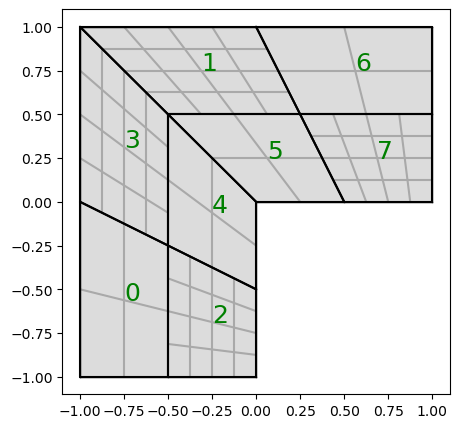

In [19]:
M.plotmesh(knots=1,patch_idx=1)